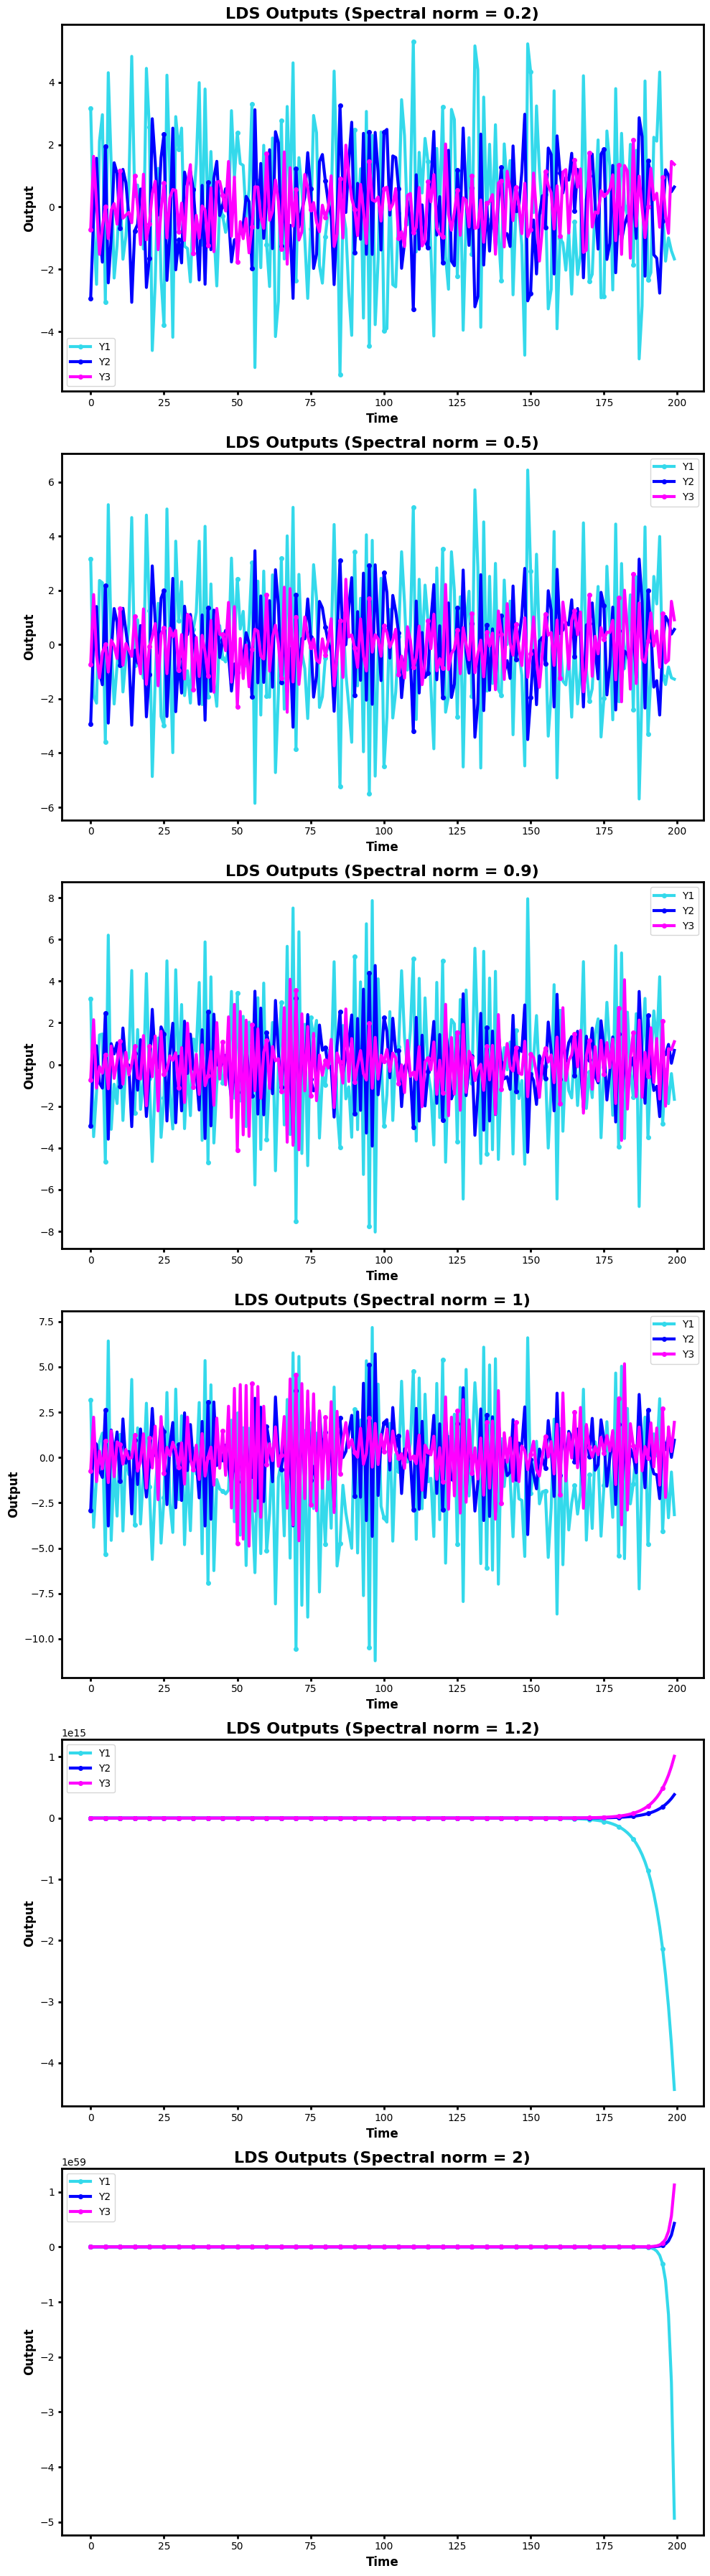

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# LDS system with spectral norm control
# ------------------------------
def system_lds_spectral(T, d_hid, d_in, d_out, rho=0.9, seed=0):
    """
    rho: desired spectral norm of A
    """
    np.random.seed(seed)

    # Random orthogonal matrix
    Q, _ = np.linalg.qr(np.random.randn(d_hid, d_hid))
    # Random eigenvalues scaled to have max absolute value = rho
    eigvals = np.random.uniform(-1, 1, size=d_hid)
    eigvals = rho * eigvals / np.max(np.abs(eigvals))
    
    # Construct A
    A = Q @ np.diag(eigvals) @ Q.T

    # Random B and C
    B = np.random.randn(d_hid, d_in)
    C = np.random.randn(d_out, d_hid)

    x = np.random.uniform(-1, 1, size=(d_hid, 1))
    U = np.zeros((T, d_in))
    Y = np.zeros((T, d_out))

    for t in range(T):
        u = np.random.uniform(-1, 1, size=(d_in, 1))
        U[t] = u.flatten()
        y = C @ x
        Y[t] = y.flatten()
        x = A @ x + B @ u

    return U, Y

# ------------------------------
# Simulation parameters
# ------------------------------
T = 200
d_hid = 5
d_in = 2
d_out = 3
spectral_norms = [0.2, 0.5, 0.9, 1, 1.2, 2]  # Different rho values

# ------------------------------
# Plot outputs for different spectral norms
# ------------------------------
colors = ['#34d9eb', '#0000ff', '#ff00ff']  # Y channels
labels = [f'Y{i+1}' for i in range(d_out)]

fig, axs = plt.subplots(len(spectral_norms), 1, figsize=(10, 6*len(spectral_norms)))

for idx, rho in enumerate(spectral_norms):
    U, Y = system_lds_spectral(T, d_hid, d_in, d_out, rho=rho, seed=42)
    ax = axs[idx]
    time = np.arange(T)

    for i in range(d_out):
        ax.plot(time, Y[:, i], lw=3, color=colors[i], label=labels[i], marker='o', markersize=4, markevery=5)

    ax.set_title(f"LDS Outputs (Spectral norm = {rho})", fontsize=16, fontweight='bold')
    ax.set_xlabel("Time", fontsize=12, fontweight='bold')
    ax.set_ylabel("Output", fontsize=12, fontweight='bold')
    ax.tick_params(width=2, labelsize=10)
    ax.legend(fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()